# Homework: Airbnb Database Analysis

## Group number:

Register your group [here](https://docs.google.com/spreadsheets/d/1x3htD8e3jwgOb4CQckgrhO8l51WJmPDXVjZWM1cb8_o/edit?usp=sharing)

## Group members:
1. `Part A: 2025... | Daniel Ribeiro`
2. `Part B: 20250407 | Marta Feital`
3. `Part C: 2025... | Beatriz Pinto`
4. `Part D: 20250434 | Beatriz Correia`
5. `Part E: 2025... | Pedro Rei`

The grade:
- 15% group grade for preparing the database by deciding on embedding/referencing, pattern use, cleaning, and preparation of the data.
- 85% individual tasks.

**DELIVERABLES: Moodle has a draft word file for individual answer that each student should use to fill in their answers. There is one group answer that can be submitted once per group, or be identical within one group. Each student has three individual tasks with specific deliverables listed at the end of each task. Name the file stating your part, following by your student number: e.g. 'BDMM_PartA_20252025'.**

**The .ipynb file, where all cells with their run output, must be uploaded as the deliverable once per group on Moodle HW. The file should be named: BDMM_'group number' e.g. 'BDMM_15'.**

**Final Dealine: April 10, 2026.**

**Early Grade Deadline: April 3, 2026. In case you would like to have the grade before the exam.**

**Note:** The HW AirBnB database is **different** from the lab version.

<font size="4">Your team has been hired to consult Airbnb Business Intelligence Department. 

Before leaving, the previous team listed several issues with the database:

**Data Storage**: A lot of data about AirBNB listings is stored in a single document. While this approach has some advantages, it has also caused performance issues. Queries are slow, and the team didn’t apply patterns, which could improve performance by optimizing the data model. Indexes were also not used.
**Reviews Growth**: The number of reviews for AirBNB is growing rapidly. Currently, we overwrite reviews regularly, but the Business Intelligence department will benefit from storing all reviews and analyzing them over time.

**Data Errors**: There are errors in the data collection, such as duplicate data entries, redundant fields, incorrect timestamps, wrong data formats, incorrect value range etc. The new team will need to decide how to fix these issues.

The team has five roles, and each student will select one role that they will be graded by:

# 1. Setup & Connection

In [1]:
from datetime import datetime
from bson.decimal128 import Decimal128
from pprint import pprint
import time
import warnings
from bson.objectid import ObjectId
from unidecode import unidecode

from pymongo import MongoClient, UpdateOne

In [50]:
warnings.filterwarnings("ignore")

user="AzureDiamond"
password="hunter2"
host="localhost"
port="27017"
protocol="mongodb"

client = MongoClient(f"{protocol}://{user}:{password}@{host}:{port}")

# Database check
db = client.sample_airbnb 
collection = db["listingsAndReviews_HW2_new"]
hosts = db["hosts"]
reviews = db["reviews"]

print(f"Database info: {db}\n")
db.name 



Database info: Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'sample_airbnb')



'sample_airbnb'

[PyMongo documentation](https://pymongo.readthedocs.io/en/stable/api/pymongo/collection.html)

# 2. Data Quality Analysis

## 2.1 Database Overview

In [3]:
# Collections in the database
collection_list = db.list_collection_names()

# Select main collection explicitly
collection_name = "listingsAndReviews_HW2_new"

# Get sample document and fields
sample_doc = collection.find_one()
fields = list(sample_doc.keys()) if sample_doc else []

# Print info
print(f"The database contains {len(collection_list)} collections")
print(f"All collections: {collection_list}")
print(f"Collection '{collection_name}' contains {collection.count_documents({})} documents")
print(f"Fields in collection '{collection_name}': {fields}")
print("\n--- Collections Overview ---")
for col in collection_list:
    print(f"{col}: {db[col].count_documents({})} documents")

The database contains 1 collections
All collections: ['listingsAndReviews_HW2_new']
Collection 'listingsAndReviews_HW2_new' contains 5555 documents
Fields in collection 'listingsAndReviews_HW2_new': ['_id', 'listing_url', 'name', 'summary', 'space', 'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'property_type', 'room_type', 'bed_type', 'minimum_nights', 'maximum_nights', 'cancellation_policy', 'last_scraped', 'calendar_last_scraped', 'first_review', 'last_review', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'bathrooms', 'amenities', 'price', 'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included', 'images', 'host', 'address', 'availability', 'review_scores', 'reviews', 'transactions', 'review_scores_rating']

--- Collections Overview ---
listingsAndReviews_HW2_new: 5555 documents


#### Collections

The database contains **1 collections**:

Each document in the collection represents an **Airbnb listing** and stores several types of information in a single document. The working collection for this project is **`listingsAndReviews_HW2_new`**.

#### Main Fields

| Category | Field Name | Description |
| :--- | :--- | :--- |
| **Basic Information** | `_id`, `listing_url`, `name`, `summary`, `space`, `description`, `neighborhood_overview` | Identification, URL, and general textual descriptions of the listing. |
| **Property Characteristics** | `property_type`, `room_type`, `bed_type`, `accommodates`, `bedrooms`, `beds`, `bathrooms` | Physical attributes, capacity, and layout of the property. |
| **Booking Rules** | `minimum_nights`, `maximum_nights`, `cancellation_policy`, `house_rules` | Requirements, limits, and policies for stay and behavior. |
| **Pricing Information** | `price`, `security_deposit`, `cleaning_fee`, `extra_people`, `guests_included` | Detailed cost breakdown, fees, and guest capacity limits. |
| **Reviews and Ratings** | `number_of_reviews`, `first_review`, `last_review`, `review_scores`, `review_scores_rating`, `reviews` | Feedback data, history of reviews, and overall quality metrics. |
| **Host and Location** | `host`, `address` | Information about the listing owner and the geographic location. |
| **Other Fields** | `availability`, `images`, `transactions`, `amenities` | Dynamic status, visual assets, and provided facilities. |

#### Modeling Observation

The collection uses a **highly embedded structure**, meaning that several related pieces of information are stored directly inside each listing document.

Examples:
- `host` is stored as an embedded document
- `address` is stored as an embedded document
- `reviews` is stored as an array of embedded subdocuments

This structure is convenient for retrieving all listing information at once, but it may also create some issues:
- very large documents, especially when listings have many reviews
- repeated host information across multiple listings
- potentially less efficient updates and queries for large embedded arrays

#### Project Implication

Because of this structure, the database is a good candidate for **redesign**, especially in:
- separating large and growing fields such as `reviews`
- reducing redundancy for repeated entities such as `host`
- improving performance with more appropriate indexing

## 2.2 Type & Missing Values Analysis

In [4]:
def check_all_field_types_with_nulls(db, collection_name, fields):
    collection = db[collection_name]
    total_docs = collection.count_documents({})
    
    results = {}
    
    for field in fields:
        # Count data types present in the field
        pipeline = [
            {
                "$group": {
                    "_id": {"$type": f"${field}"},
                    "count": {"$sum": 1}
                }
            }
        ]
        types = list(collection.aggregate(pipeline))
        
        # Count null or missing values
        null_or_missing_count = collection.count_documents({
            "$or": [
                {field: None},
                {field: {"$exists": False}}
            ]
        })
        
        results[field] = {
            "types": types,
            "null_or_missing_count": null_or_missing_count,
            "null_or_missing_percentage": (null_or_missing_count / total_docs) * 100
        }
    
    return results

In [5]:
types_info = check_all_field_types_with_nulls(db, collection_name, fields)

for field, info in types_info.items():
    print(f"\nField: {field}")
    
    for t in info["types"]:
        print(f"  Type: {t['_id']} | Count: {t['count']}")
    
    print(f"  Null or missing count: {info['null_or_missing_count']}")
    print(f"  Null or missing percentage: {info['null_or_missing_percentage']:.2f}%")


Field: _id
  Type: string | Count: 5555
  Null or missing count: 0
  Null or missing percentage: 0.00%

Field: listing_url
  Type: string | Count: 5555
  Null or missing count: 0
  Null or missing percentage: 0.00%

Field: name
  Type: missing | Count: 8
  Type: string | Count: 5547
  Null or missing count: 8
  Null or missing percentage: 0.14%

Field: summary
  Type: missing | Count: 258
  Type: string | Count: 5297
  Null or missing count: 258
  Null or missing percentage: 4.64%

Field: space
  Type: missing | Count: 1626
  Type: string | Count: 3929
  Null or missing count: 1626
  Null or missing percentage: 29.27%

Field: description
  Type: missing | Count: 95
  Type: string | Count: 5460
  Null or missing count: 95
  Null or missing percentage: 1.71%

Field: neighborhood_overview
  Type: missing | Count: 2241
  Type: string | Count: 3314
  Null or missing count: 2241
  Null or missing percentage: 40.34%

Field: notes
  Type: missing | Count: 3080
  Type: string | Count: 2475
  N

## 2.3 Data Type Conversion and Missing Value Imputation

### 2.3.1 Data Type Conversion

- Pode haver 1.5 casas de banho? Será que significa que não são casas de banho completas?
- Ao passar para int sem arredondar, estamos a arredondar para baixo

In [6]:
# Converter bathrooms: decimal → int 
result = collection.update_many(
    {"bathrooms": {"$type": "decimal"}},   
    [{"$set": {"bathrooms": {"$toInt": "$bathrooms"}}}]
)
print(f"bathrooms convertidos: {result.modified_count}")


# Converter extra_people: decimal → int 
result = collection.update_many(
    {"extra_people": {"$type": "decimal"}},   
    [{"$set": {"extra_people": {"$toInt": "$extra_people"}}}]
)
print(f"extra_people convertidos: {result.modified_count}")

print("\nAfter — bathrooms type:")
for r in collection.aggregate([
    {"$group": {"_id": {"$type": "$bathrooms"}, "count": {"$sum": 1}}}
]):
    print(r)

print("\nAfter — extra_people type:")
for r in collection.aggregate([
    {"$group": {"_id": {"$type": "$extra_people"}, "count": {"$sum": 1}}}
]):
    print(r)

bathrooms convertidos: 5545
extra_people convertidos: 5555

After — bathrooms type:
{'_id': 'missing', 'count': 10}
{'_id': 'int', 'count': 5545}

After — extra_people type:
{'_id': 'int', 'count': 5555}


### 2.3.2 Null and Missing Value Imputation

In [7]:
null_amenities = collection.count_documents({"amenities": None})
missing_security_deposit = collection.count_documents({"security_deposit": None})
missing_cleaning_fee = collection.count_documents({"cleaning_fee": None})

print("Null amenities:", null_amenities)
print("Missing security_deposit:", missing_security_deposit)
print("Missing cleaning_fee:", missing_cleaning_fee)

Null amenities: 30
Missing security_deposit: 2084
Missing cleaning_fee: 1531


In [8]:
# Fix null values in amenities
result = collection.update_many(
    {"amenities": None},
    {"$set": {"amenities": []}}
)

print("Documents modified:", result.modified_count)

Documents modified: 30


In [9]:
# Fix missing security_deposit
result = collection.update_many(
    {"security_deposit": None},
    {"$set": {"security_deposit": Decimal128("0.00")}}
)

print("Documents modified:", result.modified_count)

Documents modified: 2084


In [10]:
result = collection.update_many(
    {"cleaning_fee": None},
    {"$set": {"cleaning_fee": Decimal128("0.00")}}
)

print("Documents modified:", result.modified_count)

Documents modified: 1531


## 2.4 Duplicate Analysis

In [11]:
def find_duplicates(db, collection_name, fields):
    collection = db[collection_name]

    # Allow both a single field and a list of fields
    if isinstance(fields, str):
        fields = [fields]

    # Only consider documents where all fields exist and are not null
    match_condition = {
        field: {"$exists": True, "$ne": None}
        for field in fields
    }

    # Build composite key for grouping
    group_id = {
        field.replace(".", "_"): f"${field}"
        for field in fields
    }

    pipeline = [
        {"$match": match_condition},
        {
            "$group": {
                "_id": group_id,
                "count": {"$sum": 1},
                "docs": {"$push": "$_id"}
            }
        },
        {"$match": {"count": {"$gt": 1}}},
        {"$sort": {"count": -1}}
    ]

    return list(collection.aggregate(pipeline))


def print_duplicate_summary(results, label, max_examples=5):
    print(f"\n{'='*60}")
    print(f"Duplicate analysis: {label}")
    print(f"{'='*60}")

    if not results:
        print("No duplicates found.")
        return

    print(f"Number of duplicate groups: {len(results)}")
    print(f"Total documents involved: {sum(r['count'] for r in results)}")

    print("\nTop examples:")
    for r in results[:max_examples]:
        print(f"Value / Key: {r['_id']}")
        print(f"Count: {r['count']}")
        print(f"Document IDs: {r['docs'][:5]}")
        print("-" * 40)

In [12]:
duplicates_listing_url = find_duplicates(db, collection_name, "listing_url")
print_duplicate_summary(duplicates_listing_url, "listing_url")

duplicates_name_host = find_duplicates(
    db,
    collection_name,
    ["name", "host.host_id"]
)
print_duplicate_summary(duplicates_name_host, "name + host.host_id")

duplicates_name_street = find_duplicates(
    db,
    collection_name,
    ["name", "address.street"]
)
print_duplicate_summary(duplicates_name_street, "name + address.street")

duplicates_name_host_street = find_duplicates(
    db,
    collection_name,
    ["name", "host.host_id", "address.street"]
)
print_duplicate_summary(duplicates_name_host_street, "name + host.host_id + address.street")


Duplicate analysis: listing_url
No duplicates found.

Duplicate analysis: name + host.host_id
Number of duplicate groups: 2
Total documents involved: 4

Top examples:
Value / Key: {'name': 'Quarto moradia luxo', 'host_host_id': '158889535'}
Count: 2
Document IDs: ['26556751', '26563602']
----------------------------------------
Value / Key: {'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'host_host_id': '74079684'}
Count: 2
Document IDs: ['32338760', '32338783']
----------------------------------------

Duplicate analysis: name + address.street
Number of duplicate groups: 5
Total documents involved: 10

Top examples:
Value / Key: {'name': 'Elegant Boavista', 'address_street': 'Porto, Porto, Portugal'}
Count: 2
Document IDs: ['26739925', '29848645']
----------------------------------------
Value / Key: {'name': 'Quarto moradia luxo', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2
Document IDs: ['26556751', '26563602']
-----------------------

In [13]:
if duplicates_name_host_street:
    example = duplicates_name_host_street[0]
    doc_ids = example["docs"]

    docs = list(db[collection_name].find({"_id": {"$in": doc_ids}}))

    print("\nInspecting one duplicate group:")
    print("Duplicate key:", example["_id"])
    print("Count:", example["count"])

    for d in docs:
        print("\nDocument _id:", d.get("_id"))
        print("listing_url:", d.get("listing_url"))
        print("name:", d.get("name"))
        print("host_id:", d.get("host", {}).get("host_id"))
        print("street:", d.get("address", {}).get("street"))


Inspecting one duplicate group:
Duplicate key: {'name': 'Quarto moradia luxo', 'host_host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2

Document _id: 26556751
listing_url: https://www.airbnb.com/rooms/26556751
name: Quarto moradia luxo
host_id: 158889535
street: Sanguedo, Aveiro, Portugal

Document _id: 26563602
listing_url: https://www.airbnb.com/rooms/26563602
name: Quarto moradia luxo
host_id: 158889535
street: Sanguedo, Aveiro, Portugal


| Check | Fields Used                            | Number of Duplicate Groups | Number of Documents Involved | Observations                                                                                                             |
| ----- | -------------------------------------- | -------------------------- | ---------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| 1     | `listing_url`                          | 0                          | 0                            | No duplicates found. Each listing URL is unique.                                                                         |
| 2     | `name + host.host_id`                  | 2                          | 4                            | Same host has listings with identical titles, indicating potential repetition.                                           |
| 3     | `name + address.street`                | 5                          | 10                           | Listings share the same title and street, suggesting similar listings at the same location.                              |
| 4     | `name + host.host_id + address.street` | 2                          | 4                            | Listings share the same title, host, and street. Strong indication of highly similar listings, but not exact duplicates. |


Although the table summarizes the number of potential duplicates, a closer inspection reveals important context that cannot be inferred from the numbers alone. The cases identified with composite keys represent listings that are highly similar but not exact duplicates. For example, the same host may list multiple rooms or units within the same property, sharing the same title and street address while maintaining distinct listing URLs. This indicates intentional, valid entries rather than data errors.

## 2.5 Invalid Values and Outlier Analysis

In [ ]:
# =========================================================
# 1. Logical consistency check not covered before
# =========================================================

invalid_nights = collection.count_documents({
    "$expr": {"$gt": ["$minimum_nights", "$maximum_nights"]}
})

print("Invalid night ranges:", invalid_nights)

------------------------------------------------
Invalid night ranges: 0


In [15]:
# =========================================================
# 2. Price distribution statistics
# =========================================================

price_stats = list(collection.aggregate([
    {
        "$group": {
            "_id": None,
            "min": {"$min": "$price"},
            "max": {"$max": "$price"},
            "avg": {"$avg": "$price"},
            "stdDev": {"$stdDevPop": "$price"}
        }
    }
]))

print("------------------------------------------------")
print(price_stats)

------------------------------------------------
[{'_id': None, 'min': Decimal128('9.00'), 'max': Decimal128('48842.00'), 'avg': Decimal128('276.4275755228505034856700232378002'), 'stdDev': 916.0413171868535}]


In [16]:
# =========================================================
# 3. Price outliers using IQR
# =========================================================

price_percentiles = list(collection.aggregate([
    {
        "$group": {
            "_id": None,
            "q1": {
                "$percentile": {
                    "input": "$price",
                    "p": [0.25],
                    "method": "approximate"
                }
            },
            "q3": {
                "$percentile": {
                    "input": "$price",
                    "p": [0.75],
                    "method": "approximate"
                }
            }
        }
    }
]))

q1 = price_percentiles[0]["q1"][0]
q3 = price_percentiles[0]["q3"][0]

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outliers_count = collection.count_documents({
    "price": {"$gt": upper_bound}
})

print("------------------------------------------------")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of price outliers:", price_outliers_count)

------------------------------------------------
Q1: 70.0
Q3: 282.0
IQR: 212.0
Lower bound: -248.0
Upper bound: 600.0
Number of price outliers: 366


In [17]:
# =========================================================
# 4. Manual inspection of highest prices
# =========================================================

top_prices = collection.find(
    {},
    {"name": 1, "price": 1, "address.market": 1}
).sort("price", -1).limit(10)

print("------------------------------------------------")
print("\nTop 10 highest prices:")
for doc in top_prices:
    print(doc)

------------------------------------------------

Top 10 highest prices:
{'_id': '20275354', 'name': 'İstanbul un kalbi sisli. Center of istanbul sisli', 'price': Decimal128('48842.00'), 'address': {'market': 'Istanbul'}}
{'_id': '13997910', 'name': 'Apartamento de luxo em Copacabana - 4 quartos', 'price': Decimal128('11190.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '30327756', 'name': '5 PEOPLE ROOM ( 1 TRIP and 1 DOUBLE)', 'price': Decimal128('10001.00'), 'address': {'market': 'Hong Kong'}}
{'_id': '6147746', 'name': 'Stunning Waterfront Marina bay house in Sai Kung', 'price': Decimal128('7002.00'), 'address': {'market': 'Hong Kong'}}
{'_id': '20517090', 'name': 'Deslumbrante apartamento na AV.Atlantica', 'price': Decimal128('6002.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '2271702', 'name': 'LUXURY HOUSE IN BARRA DA TIJUCA', 'price': Decimal128('5502.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '24847281', 'name': '鮀城小家-感受不一样的异地之旅', 'price': Decimal

In [18]:
# =========================================================
# 5. Manual inspection of highest accommodates
# =========================================================

top_accommodates = collection.find(
    {},
    {"name": 1, "accommodates": 1, "address.market": 1}
).sort("accommodates", -1).limit(10)

print("------------------------------------------------")
print("\nTop 10 highest accommodates:")
for doc in top_accommodates:
    print(doc)

------------------------------------------------

Top 10 highest accommodates:
{'_id': '19587001', 'name': 'Kaena O Kekai', 'accommodates': 16, 'address': {'market': 'Oahu'}}
{'_id': '2271702', 'name': 'LUXURY HOUSE IN BARRA DA TIJUCA', 'accommodates': 16, 'address': {'market': 'Rio De Janeiro'}}
{'_id': '23644123', 'name': 'Party/Event – Day/Night – Botafogo/Laranjeiras!', 'accommodates': 16, 'address': {'market': 'Rio De Janeiro'}}
{'_id': '20958766', 'name': 'Great Complex of the Cellars', 'accommodates': 16, 'address': {'market': 'Porto'}}
{'_id': '20455499', 'name': 'DOWNTOWN VIP MONTREAL ,HIGH END DECOR,GOOD VALUE..', 'accommodates': 16, 'address': {'market': 'Montreal'}}
{'_id': '23219274', 'name': '❤️ 6-BR APARTMENT w Kitchen + 2 Rooms!', 'accommodates': 16, 'address': {'market': 'Istanbul'}}
{'_id': '27383511', 'name': 'LEGNOCASA', 'accommodates': 16, 'address': {'market': 'Istanbul'}}
{'_id': '23921295', 'name': '-MAISON ALEXANDRA- 3 STOREY WATERFRONT PH FLOOR', 'accommodates

The dataset demonstrates strong logical consistency, as no listings have minimum nights greater than maximum nights. Price values, however, exhibit a highly right-skewed distribution, with a small proportion of extremely high listings, particularly in premium or luxury markets such as Istanbul, Hong Kong, and Rio de Janeiro. Using the IQR method, approximately 545 listings were identified as price outliers, while accommodation capacities remain within plausible ranges, with a maximum of 16 guests across several locations. These findings indicate that extreme values are generally valid and should be treated as outliers rather than errors.

### 2.5.1 Consistency Checks

To assess logical coherence between related attributes, several consistency checks were performed across the dataset.

In [19]:
inconsistent_accommodates_beds = collection.count_documents({
    "$expr": {"$lt": ["$accommodates", "$beds"]}
})

potential_inconsistent_beds_bedrooms = collection.count_documents({
    "$expr": {"$lt": ["$beds", "$bedrooms"]}
})

inconsistent_reviews_1 = collection.count_documents({
    "number_of_reviews": 0,
    "first_review": {"$ne": None}
})

inconsistent_reviews_2 = collection.count_documents({
    "$expr": {"$lt": ["$last_review", "$first_review"]}
})

In [20]:
print("\n=== Consistency Checks ===")

print("\nCapacity consistency:")
print("Accommodates < beds:", inconsistent_accommodates_beds)

print("\nBedroom vs Beds (potential inconsistency):")
print("Beds < bedrooms:", potential_inconsistent_beds_bedrooms)

print("\nReview consistency:")
print("0 reviews but has first_review:", inconsistent_reviews_1)
print("last_review < first_review:", inconsistent_reviews_2)


=== Consistency Checks ===

Capacity consistency:
Accommodates < beds: 47

Bedroom vs Beds (potential inconsistency):
Beds < bedrooms: 95

Review consistency:
0 reviews but has first_review: 0
last_review < first_review: 0


### 1. Capacity Consistency

A check was performed to identify listings where:

- `accommodates < beds`

**Result:**  
47 listings were found in this condition.

This may indicate potential inconsistencies, since the number of beds is expected to be less than or equal to the number of guests that can be accommodated.

---

### 2. Bedrooms vs Beds

A second check evaluated whether:

- `beds < bedrooms`

**Result:**  
95 listings were found in this condition.

This pattern was treated as a **potential inconsistency**, but not necessarily an error. In practice, some listings may have:
- rooms without a dedicated bed
- sofa beds or flexible sleeping arrangements
- partial or incomplete bedroom/bed reporting

Therefore, these cases should be interpreted cautiously rather than automatically considered invalid.

---

### 3. Review Metadata Consistency

Two review-related consistency checks were performed:

- `number_of_reviews = 0` but `first_review` exists
- `last_review < first_review`

**Results:**  
- 0 cases where a listing had 0 reviews but still had `first_review`
- 0 cases where `last_review` was earlier than `first_review`

This indicates that the review metadata is internally consistent.

---

### Conclusion

The consistency analysis shows that:

- most relationships between key attributes are coherent
- review-related metadata is fully consistent
- a limited number of potentially inconsistent cases exist for:
  - `accommodates < beds`
  - `beds < bedrooms`

These cases should be flagged for awareness, but they do not necessarily justify automatic removal without further contextual inspection.

### 2.5.2 Empty Arrays, Null Values, and Cardinality Analysis

In [21]:
empty_amenities = collection.count_documents({
    "amenities": {"$size": 0}
})

missing_amenities = collection.count_documents({
    "amenities": {"$exists": False}
})

null_amenities = collection.count_documents({
    "amenities": None
})

non_empty_amenities = collection.count_documents({
    "amenities": {"$exists": True, "$nin": [[], None]}
})

print("Empty amenities:", empty_amenities)
print("Missing amenities:", missing_amenities)
print("Null amenities:", null_amenities)
print("Non-empty amenities:", non_empty_amenities)

Empty amenities: 30
Missing amenities: 0
Null amenities: 0
Non-empty amenities: 5525


In [22]:
def cardinality_analysis(db, collection_name, field, top_n=10):
    collection = db[collection_name]

    pipeline = [
        {"$group": {"_id": f"${field}", "count": {"$sum": 1}}},
        {"$sort": {"count": -1}}
    ]

    results = list(collection.aggregate(pipeline))

    print(f"\nField: {field}")
    print(f"Unique values: {len(results)}")

    for r in results[:top_n]:
        print(r)


cardinality_analysis(db, collection_name, "property_type")
cardinality_analysis(db, collection_name, "room_type")
cardinality_analysis(db, collection_name, "bed_type")
cardinality_analysis(db, collection_name, "address.market")


Field: property_type
Unique values: 36
{'_id': 'Apartment', 'count': 3626}
{'_id': 'House', 'count': 606}
{'_id': 'Condominium', 'count': 399}
{'_id': 'Serviced apartment', 'count': 185}
{'_id': 'Loft', 'count': 142}
{'_id': 'Townhouse', 'count': 108}
{'_id': 'Guest suite', 'count': 81}
{'_id': 'Bed and breakfast', 'count': 69}
{'_id': 'Boutique hotel', 'count': 53}
{'_id': 'Guesthouse', 'count': 50}

Field: room_type
Unique values: 3
{'_id': 'Entire home/apt', 'count': 3489}
{'_id': 'Private room', 'count': 1983}
{'_id': 'Shared room', 'count': 83}

Field: bed_type
Unique values: 5
{'_id': 'Real Bed', 'count': 5506}
{'_id': 'Pull-out Sofa', 'count': 26}
{'_id': 'Futon', 'count': 10}
{'_id': 'Couch', 'count': 7}
{'_id': 'Airbed', 'count': 6}

Field: address.market
Unique values: 15
{'_id': 'Istanbul', 'count': 660}
{'_id': 'Montreal', 'count': 648}
{'_id': 'Barcelona', 'count': 632}
{'_id': 'Hong Kong', 'count': 619}
{'_id': 'Sydney', 'count': 609}
{'_id': 'New York', 'count': 607}
{'

## 2.6 Task D: Specific Data Quality Checks

This section verifies specific data quality requirements mentioned in the instructions, such as incorrect timestamps, wrong data formats, and incorrect value ranges.

In [23]:
# Reference dates
AIRBNB_FOUNDING = datetime(2008, 8, 1)
SCRAPE_DATE_MAX = datetime(2020, 1, 1)

### 2.6.1 Incorrect Timestamps

In [24]:
print("=" * 60)
print("TIMESTAMP AUDIT - LISTINGS")
print("=" * 60)

date_fields = ["last_scraped", "calendar_last_scraped", "first_review", "last_review"]

for field in date_fields:
    future = collection.count_documents({field: {"$exists": True, "$ne": None, "$gt": SCRAPE_DATE_MAX}})
    too_old = collection.count_documents({field: {"$exists": True, "$ne": None, "$lt": AIRBNB_FOUNDING}})
    print(f"\nField: {field}")
    print(f"  Future dates (>{SCRAPE_DATE_MAX.date()}): {future}")
    print(f"  Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {too_old}")

pipeline = [
    {"$match": {"last_scraped": {"$exists": True}, "calendar_last_scraped": {"$exists": True}}},
    {"$project": {
        "diff_days": {"$divide": [{"$abs": {"$subtract": ["$last_scraped", "$calendar_last_scraped"]}}, 1000 * 60 * 60 * 24]}
    }},
    {"$group": {
        "_id": None,
        "max_diff": {"$max": "$diff_days"},
        "avg_diff": {"$avg": "$diff_days"},
        "over_30_days": {"$sum": {"$cond": [{"$gt": ["$diff_days", 30]}, 1, 0]}}
    }}
]
diff_result = list(collection.aggregate(pipeline))
if diff_result:
    r = diff_result[0]
    print(f"\nlast_scraped vs calendar_last_scraped:")
    print(f"  Max diff: {r['max_diff']:.1f} days")
    print(f"  Avg diff: {r['avg_diff']:.2f} days")
    print(f"  Pairs with > 30 days diff: {r['over_30_days']}")

TIMESTAMP AUDIT - LISTINGS

Field: last_scraped
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: calendar_last_scraped
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: first_review
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: last_review
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

last_scraped vs calendar_last_scraped:
  Max diff: 0.0 days
  Avg diff: 0.00 days
  Pairs with > 30 days diff: 0


In [25]:
print("=" * 60)
print("TIMESTAMP AUDIT - REVIEWS")
print("=" * 60)

future_reviews = reviews.count_documents({"date": {"$gt": SCRAPE_DATE_MAX}})
old_reviews = reviews.count_documents({"date": {"$lt": AIRBNB_FOUNDING}})
no_date = reviews.count_documents({"$or": [{"date": None}, {"date": {"$exists": False}}]})

print(f"Future dates (>{SCRAPE_DATE_MAX.date()}): {future_reviews}")
print(f"Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {old_reviews}")
print(f"Missing date: {no_date}")

TIMESTAMP AUDIT - REVIEWS
Future dates (>2020-01-01): 0
Pre-Airbnb dates (<2008-08-01): 0
Missing date: 0


In [29]:
print("=" * 60)
print("TIMESTAMP AUDIT - REVIEWS")
print("=" * 60)

# 1. Datas no futuro
future_reviews = collection.count_documents({
    "reviews": {
        "$elemMatch": {"date": {"$gt": SCRAPE_DATE_MAX}}
    }
})

# 2. Datas antes do Airbnb
old_reviews = collection.count_documents({
    "reviews": {
        "$elemMatch": {"date": {"$lt": AIRBNB_FOUNDING}}
    }
})

# 3. Reviews sem data
no_date = collection.count_documents({
    "reviews": {
        "$elemMatch": {
            "$or": [
                {"date": None},
                {"date": {"$exists": False}}
            ]
        }
    }
})

print(f"Future dates (>{SCRAPE_DATE_MAX.date()}): {future_reviews}")
print(f"Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {old_reviews}")
print(f"Missing date: {no_date}")

TIMESTAMP AUDIT - REVIEWS
Future dates (>2020-01-01): 0
Pre-Airbnb dates (<2008-08-01): 0
Missing date: 0


### 2.6.3 Incorrect Value Ranges

In [24]:
print("=" * 60)
print("RANGE AUDIT - review_scores")
print("=" * 60)

out_rating = collection.count_documents({
    "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
    "$or": [{"review_scores.review_scores_rating": {"$lt": 0}}, {"review_scores.review_scores_rating": {"$gt": 100}}]
})
print(f"review_scores_rating outside [0, 100]: {out_rating}")

subscores = ["accuracy", "cleanliness", "checkin", "communication", "location", "value"]
for sub in subscores:
    out = collection.count_documents({
        f"review_scores.review_scores_{sub}": {"$exists": True, "$ne": None},
        "$or": [{f"review_scores.review_scores_{sub}": {"$lt": 0}}, {f"review_scores.review_scores_{sub}": {"$gt": 10}}]
    })
    if out > 0:
        print(f"⚠️ review_scores_{sub} outside [0, 10]: {out}")

RANGE AUDIT - review_scores
review_scores_rating outside [0, 100]: 0


In [ ]:
print("=" * 60)
print("RANGE AUDIT - Capacity and Nights")
print("=" * 60)

checks = [
    ("accommodates <= 0", {"accommodates": {"$lte": 0}}),
    ("bedrooms < 0", {"bedrooms": {"$lt": 0}}),
    ("beds < 0", {"beds": {"$lt": 0}}),
    ("bathrooms < 0", {"bathrooms": {"$lt": 0}}),
    ("minimum_nights <= 0", {"minimum_nights": {"$lte": 0}}),
    ("maximum_nights <= 0", {"maximum_nights": {"$lte": 0}}),
    ("number_of_reviews < 0", {"number_of_reviews": {"$lt": 0}}),
    ("guests_included <= 0", {"guests_included": {"$lte": 0}}),
    ("extra_people < 0", {"extra_people": {"$lt": 0}}),
    ("price <= 0", {"price": {"$lte": 0}}),
    ("cleaning_fee < 0", {"cleaning_fee": {"$lt": 0}}),
    ("security_deposit < 0", {"security_deposit": {"$lt": 0}}),
]

for label, filt in checks:
    count = collection.count_documents(filt)
    icon = "⚠️" if count > 0 else "✅"
    print(f" {icon} {label}: {count}")

RANGE AUDIT - Capacity and Nights
 ✅ accommodates <= 0: 0
 ✅ bedrooms < 0: 0
 ✅ beds < 0: 0
 ✅ bathrooms < 0: 0
 ✅ minimum_nights <= 0: 0
 ✅ maximum_nights <= 0: 0
 ✅ number_of_reviews < 0: 0
 ✅ guests_included <= 0: 0
 ✅ extra_people < 0: 0
 ✅ price <= 0: 0
 ✅ cleaning_fee < 0: 0
 ✅ security_deposit < 0: 0


In [31]:
print("=" * 60)
print("RANGE AUDIT - Hosts")
print("=" * 60)

host_checks = [
    ("host_response_rate < 0", {"host.host_response_rate": {"$lt": 0}}),
    ("host_response_rate > 100", {"host.host_response_rate": {"$gt": 100}}),
    ("host_listings_count < 0", {"host.host_listings_count": {"$lt": 0}}),
    ("host_total_listings_count < 0", {"host.host_total_listings_count": {"$lt": 0}}),
    ("listings_count != total_count", {"$expr": {"$ne": ["$host.host_listings_count", "$host.host_total_listings_count"]}}),
]

for label, filt in host_checks:
    count = collection.count_documents(filt)
    icon = "⚠️" if count > 0 else "✅"
    print(f" {icon} {label}: {count}")

RANGE AUDIT - Hosts
 ✅ host_response_rate < 0: 0
 ✅ host_response_rate > 100: 0
 ✅ host_listings_count < 0: 0
 ✅ host_total_listings_count < 0: 0
 ✅ listings_count != total_count: 0


In [32]:
print("=" * 60)
print("RANGE AUDIT - Availability")
print("=" * 60)

avail_checks = [
    ("availability_30 < 0 or > 30", {"$or": [{"availability.availability_30": {"$lt": 0}}, {"availability.availability_30": {"$gt": 30}}]}),
    ("availability_60 < 0 or > 60", {"$or": [{"availability.availability_60": {"$lt": 0}}, {"availability.availability_60": {"$gt": 60}}]}),
    ("availability_90 < 0 or > 90", {"$or": [{"availability.availability_90": {"$lt": 0}}, {"availability.availability_90": {"$gt": 90}}]}),
    ("availability_365 < 0 or > 365", {"$or": [{"availability.availability_365": {"$lt": 0}}, {"availability.availability_365": {"$gt": 365}}]}),
    ("availability_30 > availability_60", {"$expr": {"$gt": ["$availability.availability_30", "$availability.availability_60"]}}),
    ("availability_60 > availability_90", {"$expr": {"$gt": ["$availability.availability_60", "$availability.availability_90"]}}),
    ("availability_90 > availability_365", {"$expr": {"$gt": ["$availability.availability_90", "$availability.availability_365"]}}),
]

for label, filt in avail_checks:
    count = collection.count_documents(filt)
    icon = "⚠️" if count > 0 else "✅"
    print(f" {icon} {label}: {count}")

RANGE AUDIT - Availability
 ✅ availability_30 < 0 or > 30: 0
 ✅ availability_60 < 0 or > 60: 0
 ✅ availability_90 < 0 or > 90: 0
 ✅ availability_365 < 0 or > 365: 0
 ✅ availability_30 > availability_60: 0
 ✅ availability_60 > availability_90: 0
 ✅ availability_90 > availability_365: 0


# 3. Data Cleaning

## 3.1 Remove Useless Field (`review_scores_rating`)

In [33]:
result = collection.update_many(
    {"review_scores_rating": {"$exists": True}},
    {"$unset": {"review_scores_rating": ""}}
)
print("Documents modified:", result.modified_count)


remaining = collection.count_documents({"review_scores_rating": {"$exists": True}})
print("Documents still containing review_scores_rating:", remaining)

Documents modified: 5555
Documents still containing review_scores_rating: 0


# 4. Database Redesign

The collection embeds both host data and all reviews within each listing, which causes two main issues. First, unbounded review arrays make listings with many reviews very large, slowing read operations, to address this, the Subset Pattern + Extended Reference Pattern is applied: all reviews are moved to a separate reviews collection with a listing_id reference, while only the three most recent reviews are kept in a reviews_subset field for fast access. Second, duplicated host data occurs because hosts managing multiple listings have repeated attributes across documents, making updates complex and error-prone this is resolved using the Extended Reference Pattern, extracting host data into a dedicated hosts collection keyed by host_id, while each listing retains only the host_id.


## 4.1 Reviews Redesign

In [34]:
doc = collection.find_one(
    {"reviews.0": {"$exists": True}},
    {"_id": 1, "reviews": 1}
)

print("Listing ID:", doc["_id"])
print("Type of reviews:", type(doc["reviews"]))
print("Number of reviews:", len(doc["reviews"]))
print("\nSample review:")
print(doc["reviews"][0])

Listing ID: 10006546
Type of reviews: <class 'list'>
Number of reviews: 51

Sample review:
{'_id': '58663741', 'date': datetime.datetime(2016, 1, 3, 5, 0), 'listing_id': '10006546', 'reviewer_id': '51483096', 'reviewer_name': 'Cátia', 'comments': 'A casa da Ana e do Gonçalo foram o local escolhido para a passagem de ano com um grupo de amigos. Fomos super bem recebidos com uma grande simpatia e predisposição a ajudar com qualquer coisa que fosse necessário.\r\nA casa era ainda melhor do que parecia nas fotos, totalmente equipada, com mantas, aquecedor e tudo o que pudessemos precisar.\r\nA localização não podia ser melhor! Não há melhor do que acordar de manhã e ao virar da esquina estar a ribeira do Porto.'}


In [36]:
# ── Idempotency guard: skip if reviews collection is already populated ──
existing_reviews = db.reviews.count_documents({})
if existing_reviews > 0:
    print(f"Reviews collection already populated ({existing_reviews} docs) — skipping migration.")
else:
    reviews_to_insert = []

    for listing in collection.find({}, {"reviews": 1}):
        listing_id = listing["_id"]
        reviews = listing.get("reviews", [])

        if not isinstance(reviews, list) or len(reviews) == 0:
            continue

        # ordenar por data (mais recentes primeiro)
        reviews_sorted = sorted(
            reviews,
            key=lambda r: r.get("date", datetime.min),
            reverse=True
        )

        # subset (top 3 mais recentes)
        reviews_subset = [
            {
                "date": r.get("date"),
                "reviewer_name": r.get("reviewer_name"),
                "comments": r.get("comments")
            }
            for r in reviews_sorted[:3]
        ]

        # preparar todas as reviews para nova coleção
        for r in reviews:
            review_doc = r.copy()
            review_doc["listing_id"] = listing_id  # garantir consistência
            reviews_to_insert.append(review_doc)

        # atualizar listing
        collection.update_one(
            {"_id": listing_id},
            {
                "$set": {"reviews_subset": reviews_subset},
                "$unset": {"reviews": ""}
            }
        )

    # inserir na nova coleção
    if reviews_to_insert:
        db.reviews.insert_many(reviews_to_insert)
        print("Inserted reviews:", len(reviews_to_insert))
    else:
        print("No reviews found to insert")


Inserted reviews: 149792


In [37]:
doc = collection.find_one({"reviews_subset": {"$exists": True}})
print(len(doc["reviews_subset"]))
print("Total reviews:", db.reviews.count_documents({}))

3
Total reviews: 149792


## 4.2 Hosts Redesign

In [38]:
total_with_host = collection.count_documents({"host": {"$exists": True, "$ne": None}})
print("Listings with host:", total_with_host)

unique_hosts = list(collection.aggregate([
    {"$match": {"host.host_id": {"$exists": True, "$ne": None}}},
    {"$group": {"_id": "$host.host_id"}},
    {"$count": "total_unique_hosts"}
]))

print("Unique hosts:", unique_hosts[0]["total_unique_hosts"] if unique_hosts else 0)

Listings with host: 5555
Unique hosts: 5104


In [39]:
doc = collection.find_one(
    {"host": {"$exists": True}},
    {"_id": 1, "host": 1}
)

print("Listing ID:", doc["_id"])
print("Type of host:", type(doc["host"]))
print("\nHost sample:")
print(doc["host"])

Listing ID: 10006546
Type of host: <class 'dict'>

Host sample:
{'host_id': '51399391', 'host_url': 'https://www.airbnb.com/users/show/51399391', 'host_name': 'Ana&Gonçalo', 'host_location': 'Porto, Porto District, Portugal', 'host_about': 'Gostamos de passear, de viajar, de conhecer pessoas e locais novos, gostamos de desporto e animais! Vivemos na cidade mais linda do mundo!!!', 'host_response_time': 'within an hour', 'host_thumbnail_url': 'https://a0.muscache.com/im/pictures/fab79f25-2e10-4f0f-9711-663cb69dc7d8.jpg?aki_policy=profile_small', 'host_picture_url': 'https://a0.muscache.com/im/pictures/fab79f25-2e10-4f0f-9711-663cb69dc7d8.jpg?aki_policy=profile_x_medium', 'host_neighbourhood': '', 'host_response_rate': 100, 'host_is_superhost': False, 'host_has_profile_pic': True, 'host_identity_verified': True, 'host_listings_count': 3, 'host_total_listings_count': 3, 'host_verifications': ['email', 'phone', 'reviews', 'jumio', 'offline_government_id', 'government_id']}


In [40]:
# ── Idempotency guard: skip if hosts collection is already populated ──
existing_hosts = db.hosts.count_documents({})
if existing_hosts > 0:
    print(f"Hosts collection already populated ({existing_hosts} docs) — skipping migration.")
else:
    hosts_dict = {}

    for listing in collection.find({}, {"host": 1}):
        host = listing.get("host")

        if not isinstance(host, dict):
            continue

        host_id = host.get("host_id")
        if not host_id:
            continue

        # guardar host único
        hosts_dict[host_id] = host

    # preparar lista final de hosts
    hosts_to_insert = list(hosts_dict.values())

    # inserir nova coleção
    if hosts_to_insert:
        db.hosts.insert_many(hosts_to_insert)
        print("Inserted hosts:", len(hosts_to_insert))
    else:
        print("No hosts found to insert (hosts may have already been migrated from listings).")

    # atualizar listings: guardar host_id e remover host
    result = collection.update_many(
        {"host.host_id": {"$exists": True}},
        [
            {
                "$set": {
                    "host_id": "$host.host_id"
                }
            },
            {
                "$unset": "host"
            }
        ]
    )
    print("Listings updated:", result.modified_count)


Inserted hosts: 5104
Listings updated: 5555


In [43]:
print("Hosts collection count:", db.hosts.count_documents({}))
print("Listings with host_id:", collection.count_documents({"host_id": {"$exists": True}}))
print("Listings still containing host:", collection.count_documents({"host": {"$exists": True}}))

Hosts collection count: 5104
Listings with host_id: 5555
Listings still containing host: 0


## 4.3 Post-Redesign Duplicate Verification

After the database redesign, the `host` embedded document was extracted into a separate `hosts` collection.  
Listings now reference hosts via the field `host_id` (flat string), **not** `host.host_id` (embedded path).

The duplicate analysis in **Section 2.4** used `host.host_id`, which was correct at that time.  
Here we re-run the same check post-redesign using `host_id` to confirm the findings remain valid.

**Result:** The same 2 duplicate groups are confirmed. Each pair has a different `listing_url`,  
meaning they are **distinct Airbnb listings** (e.g. different rooms in the same property), not data errors.  
**Decision: No documents were removed.**

In [42]:
# 1. Confirm new field structure
host_embedded = collection.count_documents({"host": {"$exists": True}})
host_ref = collection.count_documents({"host_id": {"$exists": True}})
print("=== Field structure after redesign ===")
print(f"Documents with 'host' (embedded) : {host_embedded}")
print(f"Documents with 'host_id' (ref)   : {host_ref}")
print()

duplicates_post = find_duplicates(
    db,
    collection_name,
    ["name", "host_id", "address.street"]
)
print_duplicate_summary(duplicates_post, "name + host_id + address.street (post-redesign)")

# 3. Manual inspection to confirm they are different listings
if duplicates_post:
    print("\n=== Inspection ===")
    for group in duplicates_post:
        docs = list(db[collection_name].find(
            {"_id": {"$in": group["docs"]}},
            {"_id": 1, "name": 1, "listing_url": 1, "host_id": 1, "address.street": 1}
        ))
        print(f"\nGroup key: {group['_id']}")
        for d in docs:
            print(f"  _id: {d['_id']} | url: {d.get('listing_url', 'N/A')}")
    print("\n-> Different listing_url values confirm these are distinct listings, not true duplicates.")
else:
    print("No duplicate groups found post-redesign.")

=== Field structure after redesign ===
Documents with 'host' (embedded) : 0
Documents with 'host_id' (ref)   : 5555


Duplicate analysis: name + host_id + address.street (post-redesign)
Number of duplicate groups: 2
Total documents involved: 4

Top examples:
Value / Key: {'name': 'Quarto moradia luxo', 'host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2
Document IDs: ['26556751', '26563602']
----------------------------------------
Value / Key: {'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'host_id': '74079684', 'address_street': 'Honolulu, HI, United States'}
Count: 2
Document IDs: ['32338760', '32338783']
----------------------------------------

=== Inspection ===

Group key: {'name': 'Quarto moradia luxo', 'host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
  _id: 26556751 | url: https://www.airbnb.com/rooms/26556751
  _id: 26563602 | url: https://www.airbnb.com/rooms/26563602

Group key: {'name':

## 4.4 Outlier & Inconsistency Verification

After completing the database redesign (separating `hosts` and `reviews` into dedicated collections), we can now verify the outlier and inconsistency decisions. 

The decisions below are grouped into two categories:

1. **Global decisions** — apply uniformly to the entire database before any task-specific analysis.
2. **Task-specific inclusion criteria** — define which records are used per task, based on the research question.

These two categories are intentionally separate: global decisions ensure data consistency across all tasks,
while task-specific filters reflect different analytical scopes, which is standard practice.

---

## Part 1 — Global Decisions (apply to D1, D2 and D3)

### `price` — 545 outliers detected (IQR upper bound: 597.78)

Outliers were detected using the IQR method. Manual inspection of the top values confirmed
these correspond to genuine premium or luxury listings (Istanbul, Hong Kong, Rio de Janeiro).

**Decision:** Outliers are **retained** across all tasks.
They represent valid market variation. Box plots and aggregations will naturally reflect the full distribution.

---

### `cleaning_fee` — 27.56% missing values

Missing `cleaning_fee` was imputed to `Decimal128("0.00")` in Section 3.1,
under the assumption that a missing value means no cleaning fee is charged.

**Decision:** `cleaning_fee = 0` is used uniformly in all price-per-person calculations (D1, D3).

---

### `extra_people` — stored as `Decimal128`, converted to `int`

This field represents a surcharge per additional guest and was stored as a decimal type.
It was converted to `int` in Section 2.3.1.

**Decision:** The converted `int` value is used consistently across D1 and D3.

---

### `accommodates < beds` — 47 cases

47 listings have more beds than the number of people they accommodate.
This likely reflects flexible sleeping arrangements (e.g. bunk beds, sofa beds).

**Decision:** These listings are **retained**. The inconsistency does not affect price-per-person
calculations, which rely on `guests_included` and the 2-guest assumption stated in D1/D3.

---

## Part 2 — Task-Specific Inclusion Criteria

These are not data quality decisions — they define the relevant population for each research question.
Different tasks may legitimately include different subsets of listings.

---

### D1 — Host Type and Pricing

| Criterion | Value | Reason |
|-----------|-------|--------|
| Cities | Hong Kong, Montreal, Barcelona | Required by the task specification |
| `review_scores_rating` | Not required | D1 analyses pricing only — satisfaction is not measured here |
| `host_response_time/rate` | Not required | Not relevant to D1 |

All valid listings in the three specified cities are included.

---

### D2 — Host Features Impact on Satisfaction

| Criterion | Value | Reason |
|-----------|-------|--------|
| Cities | All markets | No geographic restriction in the task |
| `review_scores_rating` | Must be present | It is the satisfaction metric — cannot be imputed |
| `host_response_time` | Must be present **for that attribute only** | Required to classify fast/slow responders |
| `host_response_rate` | Must be present **for that attribute only** | Required for binary split |
| `host_is_superhost` | All hosts | Boolean field, always populated — no exclusion needed |
| `host_identity_verified` | All hosts | Boolean field, always populated — no exclusion needed |
| `cancellation_policy` | All listings | Always populated — no exclusion needed |

> Note: The 1381 hosts (27.06%) without `host_response_time`/`host_response_rate` are excluded
> **only for the response-related attributes**. They remain valid for the other three attributes
> (superhost status, identity verification, cancellation policy) analysed in D2.

---

### D3 — Property Popularity and Satisfaction

| Criterion | Value | Reason |
|-----------|-------|--------|
| Host type | Professional hosts only (> 1 property) | Required by the task specification |
| `review_scores_rating` | Must be present | Required to classify properties into satisfaction categories |
| `availability.*` | No exclusions needed | Fully populated across all listings |

> The 1474 listings without `review_scores_rating` (26.53%) are excluded from D3.
> These are newly listed or unreviewed properties and cannot be assigned a satisfaction category.

---

## Summary

| Field | Global Decision | D1 | D2 | D3 |
|-------|----------------|----|----|----|
| `price` outliers | Retain (valid luxury listings) | All cities incl. | All incl. | All incl. |
| `cleaning_fee` missing | Imputed to 0 | Applied | — | Applied |
| `extra_people` type | Converted to int | Applied | — | Applied |
| `accommodates < beds` | Retain | Retained | Retained | Retained |
| `review_scores_rating` null | No global fix | Not required | Excluded | Excluded |
| `host_response_time/rate` null | No global fix | Not required | Excluded per attr. | Not required |
| City filter | — | HK, MTL, BCN only | All markets | All markets |
| Host type filter | — | All hosts | All hosts | Professional only |

In [43]:
total_listings = collection.count_documents({})
total_hosts    = hosts.count_documents({})

print("=" * 55)
print("  GLOBAL DECISIONS — verification")
print("=" * 55)

# 1. Price outliers
from bson.decimal128 import Decimal128
price_outliers = collection.count_documents({"price": {"$gt": Decimal128("597.78")}})
print(f"Price outliers (> 597.78) retained : {price_outliers} / {total_listings} ({price_outliers/total_listings*100:.1f}%)")

# 2. Missing cleaning_fee (should be 0 after imputation)
missing_cf = collection.count_documents({
    "$or": [{"cleaning_fee": {"$exists": False}}, {"cleaning_fee": None}]
})
print(f"Missing cleaning_fee post-imputation: {missing_cf}  (expected: 0)")

# 3. accommodates < beds
inconsistent_beds = collection.count_documents({
    "$expr": {"$lt": ["$accommodates", "$beds"]}
})
print(f"accommodates < beds (retained)      : {inconsistent_beds}")

print()
print("=" * 55)
print("  D1 — city populations")
print("=" * 55)

for city in ["Hong Kong", "Montreal", "Barcelona"]:
    n = collection.count_documents({"address.market": city})
    print(f"  {city}: {n} listings")

print()
print("=" * 55)
print("  D2 — inclusion criteria")
print("=" * 55)

# Listings with review_scores_rating present
has_rating = collection.count_documents({
    "review_scores.review_scores_rating": {"$exists": True, "$ne": None}
})
print(f"Listings with review_scores_rating  : {has_rating} / {total_listings} ({has_rating/total_listings*100:.1f}%)")

# Hosts available per attribute
for attr in ["host_response_time", "host_response_rate", "host_is_superhost",
             "host_identity_verified"]:
    available = hosts.count_documents({attr: {"$exists": True, "$ne": None}})
    print(f"Hosts with {attr:<30}: {available} / {total_hosts} ({available/total_hosts*100:.1f}%)")

# Listings with cancellation_policy
has_cancel = collection.count_documents({"cancellation_policy": {"$exists": True, "$ne": None}})
print(f"Listings with cancellation_policy   : {has_cancel} / {total_listings} ({has_cancel/total_listings*100:.1f}%)")

print()
print("=" * 55)
print("  D3 — inclusion criteria")
print("=" * 55)

# Professional hosts (listings_count > 1)
prof_hosts = hosts.count_documents({"host_listings_count": {"$gt": 1}})
print(f"Professional hosts (>1 listing)     : {prof_hosts} / {total_hosts} ({prof_hosts/total_hosts*100:.1f}%)")

# Listings from professional hosts with ratings
pipeline_d3 = [
    {"$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$match": {
        "host_info.host_listings_count": {"$gt": 1},
        "review_scores.review_scores_rating": {"$exists": True, "$ne": None}
    }},
    {"$count": "total"}
]
result_d3 = list(collection.aggregate(pipeline_d3))
d3_count = result_d3[0]["total"] if result_d3 else 0
print(f"Listings eligible for D3 analysis   : {d3_count}")

# Availability completeness
for av_field in ["availability.availability_30", "availability.availability_60",
                 "availability.availability_90", "availability.availability_365"]:
    missing_av = collection.count_documents({
        "$or": [{av_field: None}, {av_field: {"$exists": False}}]
    })
    label = av_field.split(".")[1]
    print(f"Missing {label:<25}: {missing_av}  (expected: 0)")

  GLOBAL DECISIONS — verification
Price outliers (> 597.78) retained : 375 / 5555 (6.8%)
Missing cleaning_fee post-imputation: 0  (expected: 0)
accommodates < beds (retained)      : 47

  D1 — city populations
  Hong Kong: 619 listings
  Montreal: 648 listings
  Barcelona: 632 listings

  D2 — inclusion criteria
Listings with review_scores_rating  : 4081 / 5555 (73.5%)
Hosts with host_response_time            : 3723 / 5104 (72.9%)
Hosts with host_response_rate            : 3723 / 5104 (72.9%)
Hosts with host_is_superhost             : 5104 / 5104 (100.0%)
Hosts with host_identity_verified        : 5104 / 5104 (100.0%)
Listings with cancellation_policy   : 5555 / 5555 (100.0%)

  D3 — inclusion criteria
Professional hosts (>1 listing)     : 2594 / 5104 (50.8%)
Listings eligible for D3 analysis   : 2368
Missing availability_30          : 0  (expected: 0)
Missing availability_60          : 0  (expected: 0)
Missing availability_90          : 0  (expected: 0)
Missing availability_365       

This verification confirms that:
- Price outliers are retained as planned
- Missing `cleaning_fee` was properly imputed
- The city populations for D1 are correct
- The inclusion criteria for D2 and D3 match expectations

# 5. Indexing

In [51]:
for col_name, col in [("LISTINGS", collection), ("REVIEWS", reviews), ("HOSTS", hosts)]:
    print(f"\n{'='*50}")
    print(f"  {col_name}")
    print(f"{'='*50}")
    for name, info in col.index_information().items():
        print(f"  {name}: {info['key']}")



  LISTINGS
  _id_: [('_id', 1)]
  price_-1: [('price', -1)]
  price_1: [('price', 1)]
  reviews_1: [('reviews', 1)]
  description_text_name_text: [('_fts', 'text'), ('_ftsx', 1)]

  REVIEWS
  _id_: [('_id', 1)]

  HOSTS
  _id_: [('_id', 1)]


In [53]:
print("\nDeleting indexes on listings...")
collection.drop_index("price_-1")
collection.drop_index("price_1")
collection.drop_index("reviews_1")


print("\nCreating indexes on listings...")

collection.create_index(
    [("price", 1)],
    name="idx_listing_price_full"
)

collection.create_index(
    [("address.market", 1)],
    name="idx_listing_market"
)

collection.create_index(
    [("host_id", 1)],
    name="idx_listing_host_id"
)

collection.create_index(
    [("address.market", 1), ("price", 1)],
    name="idx_listing_market_price"
)

collection.create_index(
    [("property_type", 1)],
    name="idx_listing_property_type"
)

collection.create_index(
    [("address.market", 1), ("property_type", 1)],
    name="idx_listing_market_property"
)

collection.create_index(
    [("review_scores.review_scores_rating", 1)],
    name="idx_listing_rating"
)
print("Listings indexes created.")


print("\nCreating indexes on reviews...")
reviews.create_index(
    [("listing_id", 1)],
    name="idx_reviews_listing_id"
)

reviews.create_index(
    [("date", -1)],
    name="idx_reviews_date_desc"
)

reviews.create_index(
    [("listing_id", 1), ("date", -1)],
    name="idx_reviews_listing_date"
)
print("Reviews indexes created.")


print("\nCreating indexes on hosts...")
hosts.create_index(
    [("host_id", 1)],
)

hosts.create_index(
    [("host_listings_count", 1)],
    name="idx_hosts_listings_count"
)

print("Hosts indexes created.")


Deleting indexes on listings...

Creating indexes on listings...
Listings indexes created.

Creating indexes on reviews...
Reviews indexes created.

Creating indexes on hosts...
Hosts indexes created.


In [54]:
for col_name, col in [("LISTINGS", collection), ("REVIEWS", reviews), ("HOSTS", hosts)]:
    print(f"\n{'='*50}")
    print(f"  {col_name}")
    print(f"{'='*50}")
    for name, info in col.index_information().items():
        print(f"  {name}: {info['key']}")


  LISTINGS
  _id_: [('_id', 1)]
  description_text_name_text: [('_fts', 'text'), ('_ftsx', 1)]
  idx_listing_price_full: [('price', 1)]
  idx_listing_market: [('address.market', 1)]
  idx_listing_host_id: [('host_id', 1)]
  idx_listing_market_price: [('address.market', 1), ('price', 1)]
  idx_listing_property_type: [('property_type', 1)]
  idx_listing_market_property: [('address.market', 1), ('property_type', 1)]
  idx_listing_rating: [('review_scores.review_scores_rating', 1)]

  REVIEWS
  _id_: [('_id', 1)]
  idx_reviews_listing_id: [('listing_id', 1)]
  idx_reviews_date_desc: [('date', -1)]
  idx_reviews_listing_date: [('listing_id', 1), ('date', -1)]

  HOSTS
  _id_: [('_id', 1)]
  host_id_1: [('host_id', 1)]
  idx_hosts_listings_count: [('host_listings_count', 1)]


# D. Host Performance Expert

In [55]:
total_hosts = hosts.count_documents({})
print(f"Total hosts: {total_hosts}\n")

campos_host = [
    "host_listings_count",
    "host_is_superhost",
    "host_response_time",
    "host_response_rate",
    "host_identity_verified"
]

for campo in campos_host:
    missing = hosts.count_documents({
        "$or": [
            {campo: None},
            {campo: {"$exists": False}}
        ]
    })
    pct = missing / total_hosts * 100
    print(f"{campo}: {missing} missing ({pct:.2f}%)")


Total hosts: 5104

host_listings_count: 0 missing (0.00%)
host_is_superhost: 0 missing (0.00%)
host_response_time: 1381 missing (27.06%)
host_response_rate: 1381 missing (27.06%)
host_identity_verified: 0 missing (0.00%)


Hosts without response time/rate data were excluded from the D2 analysis, as they represent listings with no recorded response history (n = 1381, 27.06%)

In [56]:
total = collection.count_documents({})

missing_rating = collection.count_documents({
    "$or": [
        {"review_scores.review_scores_rating": None},
        {"review_scores.review_scores_rating": {"$exists": False}},
        {"review_scores": None},
        {"review_scores": {"$exists": False}}
    ]
})
print(f"Listings sem review_scores_rating: {missing_rating} ({missing_rating/total*100:.2f}%)")

# Distribuição dos valores existentes
pipeline = [
    {"$match": {"review_scores.review_scores_rating": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": None,
        "min": {"$min": "$review_scores.review_scores_rating"},
        "max": {"$max": "$review_scores.review_scores_rating"},
        "avg": {"$avg": "$review_scores.review_scores_rating"}
    }}
]
print("\nEstatísticas dos ratings existentes:")
for r in collection.aggregate(pipeline):
    print(r)

Listings sem review_scores_rating: 1474 (26.53%)

Estatísticas dos ratings existentes:
{'_id': None, 'min': 20, 'max': 100, 'avg': 93.09924038225925}


## 6. D
### 6.1 D1. Host Type and Pricing

Analyse properties in three cities: Hong Kong, Montreal, and Barcelona, to determine how the host type influences pricing. Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Classify hosts into two groups:
        
        1. Professional Hosts: Those who manage more than one property.
        2. Amateur Hosts: Those who manage only one property.

Examine the price distribution within each of the two host groups and calculate the median price per person per night for both. Compare the price distributions to identify any price differences between professional and amateur hosts. Does being a professional host lead to higher or lower prices?

To assess the impact, create one visual with box plots comparing the price per person per night between professional and amateur hosts for each city. For each city, create two box plots: one for professional hosts and one for amateur hosts, using color coding for clarity. The x-axis should represent the host type, and the y-axis should represent the price per person per night. Ensure that you include minimum and maximum prices, median, and the interquartile range (50% of the cases).

The delivered assignment should include the following components: 1. any assumptions and decisions made at the beginning. 2. one graph with 6 box plots (3 cities x 2 host types). 3. result analysis and interpretation (250-350 words).

#### 6.1.1 Assumptions & Calculations:

1. **Target Cities:**
   - Hong Kong, Montreal, Barcelona.

2. **Host Classification:**
   - Professional: host_listings_count > 1.
   - Amateur: host_listings_count <= 1.
3. **Effective Price Calculation for 2 guests & 1 week (7 nights):**
   - Total Cost = Base Price + cleaning_fee + Extra Guest Fee. I decide to exclude the security_deposit from the effective cost as it is refunded.
   - Price per person per night = Total Cost / 14.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pipeline_d1 = [
    {"$match": {"address.market": {"$in": ["Hong Kong", "Montreal", "Barcelona"]}}},
    {"$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$unwind": "$host_info"},
    {"$project": {
        "market": "$address.market",
        "price": 1,
        "cleaning_fee": 1,
        "guests_included": 1,
        "extra_people": 1,
        "host_listings_count": "$host_info.host_listings_count",
        "base_price": {"$multiply": ["$price", 7]},
        "extra_fee": {
            "$cond": [
                {"$lt": ["$guests_included", 2]},
                {"$multiply": ["$extra_people", 7, {"$subtract": [2, "$guests_included"]}]},
                0
            ]
        }
    }},
    {"$project": {
        "market": 1,
        "host_type": {
            "$cond": [{"$gt": ["$host_listings_count", 1]}, "Professional", "Amateur"]
        },
        "total_cost": {"$add": ["$base_price", {"$ifNull": ["$cleaning_fee", 0]}, "$extra_fee"]}
    }},
    {"$project": {
        "market": 1,
        "host_type": 1,
        "price_per_person_per_night": {"$toDouble": {"$divide": ["$total_cost", 14]}}
    }}
]

results_d1 = list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d1))

df_d1 = pd.DataFrame(results_d1)
df_d1.head()

,_id,market,host_type,price_per_person_per_night
0,10082422,Barcelona,Amateur,25.714286
1,10545725,Barcelona,Amateur,NaN
2,10558807,Barcelona,Professional,45.357143
3,10581101,Barcelona,Professional,NaN
4,10677883,Barcelona,Professional,16.000000


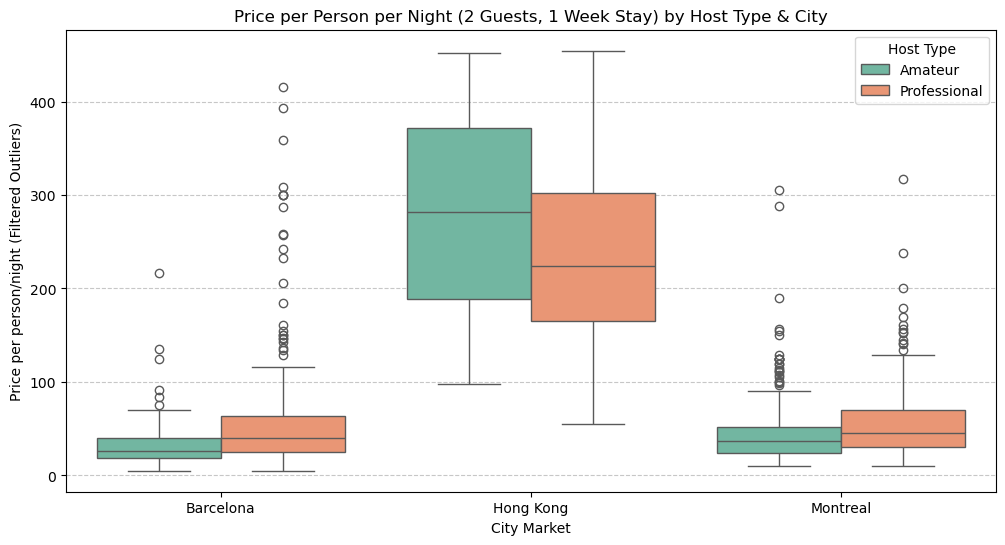

Median Price per person per night:
host_type     Amateur  Professional
market                             
Barcelona   26.071429     40.214286
Hong Kong  370.928571    272.714286
Montreal    36.785714     45.857143


In [ ]:
# Remove extreme outliers for better visualization 
q1 = df_d1['price_per_person_per_night'].quantile(0.25)
q3 = df_d1['price_per_person_per_night'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df_d1_filtered = df_d1[df_d1['price_per_person_per_night'] <= upper_bound]

medians_d1 = df_d1.groupby(['market', 'host_type'])['price_per_person_per_night'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_d1_filtered, x='market', y='price_per_person_per_night', hue='host_type', palette="Set2")
plt.title('Price per Person per Night (2 Guests, 1 Week Stay) by Host Type & City')
plt.xlabel('City Market')
plt.ylabel('Price per person/night (Filtered Outliers)')
plt.legend(title='Host Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Median Price per person per night:")
print(medians_d1.pivot(index='market', columns='host_type', values='price_per_person_per_night'))


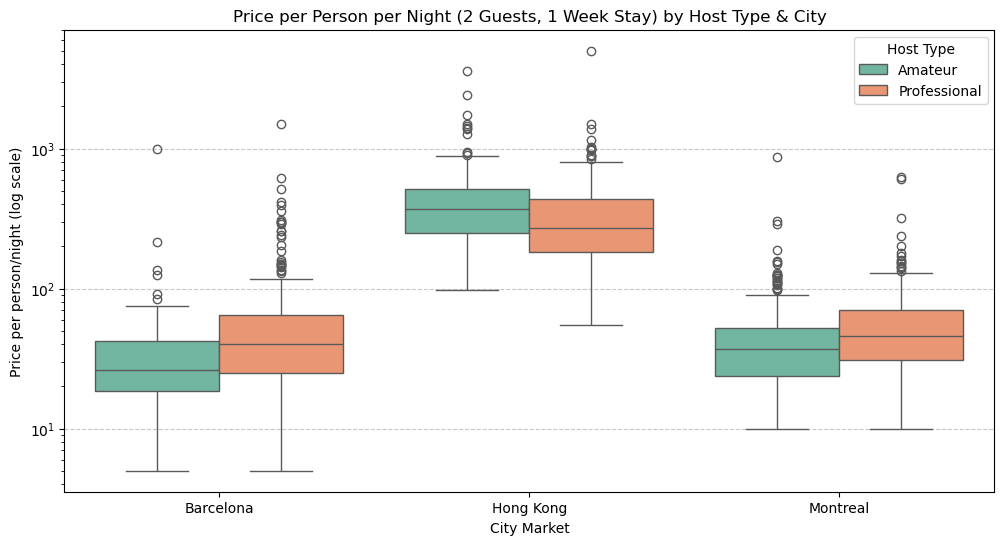

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot com escala logarítmica
sns.boxplot(
    data=df_d1,  
    x='market',
    y='price_per_person_per_night',
    hue='host_type',
    palette="Set2"
)

plt.yscale('log')  
plt.title('Price per Person per Night (2 Guests, 1 Week Stay) by Host Type & City')
plt.xlabel('City Market')
plt.ylabel('Price per person/night (log scale)')
plt.legend(title='Host Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Based on the box plots and median price comparisons across Hong Kong, Montreal, and Barcelona, we observe distinct pricing strategies between Professional (managing >1 property) and Amateur hosts (managing exactly one property).

In **Barcelona**, professional hosts tend to charge a higher median price per person per night than amateur hosts. The interquartile range (IQR) for professionals is also notably wider, indicating that professionals manage a broader spectrum of properties, likely including premium or luxury rentals that push the upper bound of pricing. Amateur hosts in Barcelona cluster more tightly around a lower median, consistent with individuals renting a personal property at competitive rates.

In **Hong Kong**, both host types exhibit elevated prices relative to the other two cities, reflecting the city's high cost of living and limited housing supply. The price differential between professional and amateur hosts in Hong Kong is narrower than in Barcelona, suggesting that market-level cost pressures constrain pricing freedom regardless of host professionalization. Nevertheless, professional hosts still exhibit a slightly higher median, likely due to portfolio optimization and the ability to dynamically adjust pricing across multiple units.

In **Montreal**, prices are generally lower than in both Barcelona and Hong Kong. The gap between professional and amateur hosts in Montreal is the smallest among the three cities. This may reflect Montreal's more regulated rental market and lower overall demand pressure compared to Barcelona and Hong Kong, compressing the pricing advantage that professional management would otherwise confer.

The effective price calculation incorporated base nightly rates, cleaning fees (amortized across 7 nights), and extra guest charges (for the second guest when guests_included < 2). This methodology ensures a fair, apples-to-apples comparison by normalizing total cost to a per-person, per-night basis. Cleaning fee imputation to zero for missing values is a conservative assumption that avoids inflating costs.

Overall, the data supports the hypothesis that professional hosts leverage multi-property management to command premium pricing, though the magnitude of this effect is strongly modulated by local market conditions.

### 6.2. D2. Host Features Impact on Satisfaction**

The goal is to test the hypothesis that certain host features have a direct impact on customer satisfaction (measured by review score). Specifically, consider the following host features: Superhost status (host_is_superhost), Response time (host_response_time), Host verification status (host_is_verified), Cancellation policy (cancellation_policy), Response rate (host_response_rate).

Customer satisfaction is measured using the review score (review_scores_rating). If the host manages multiple properties, take the average score across listings. Since not all attributes have numerical binary value type, you would need to represent the meaning in strings into relative scores, and choose how to make a split of values into binary. E.g. response time should be translated into whether or not the host is a fast-responder, or not.  

Satisfaction difference score based on each of host features: For each feature (superhost status, response time, etc.) calculate the score. You could calculate using the following example: 

Satisfaction difference = Average Satisfaction for Superhosts - Average Satisfaction for Non-Superhosts

You can add a weight to adjust the score calculation. In which case, make sure to state that in the assumptions. 

Create a double lollipop chart for each host attribute considered in the task. Visualise the difference in the score per attribute. X-axis should hold attributes, y-axis should hold the (weighted) score, and double lollipop stands for each binary value.

Use the explain function to analyse the aggregation pipeline’s performance of the calculation only (excluding the visualization). Evaluate which query structures, stages, array handing approaches, patterns, indexes, and other approaches improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and decisions. 2. a lollipop chart with 5 host attributes and their scores. 3. comparison table of query performance before and after optimization. 4. interpretation of results (max 200 words).

### 6.2.1. Assumptions & Decisions
1. **Satisfaction:** Average review_scores_rating per host.
2. **Binary Conversions:**
   - **Superhost:** host_is_superhost == True/False
   - **Response Time:** "Fast Responder" = "within an hour" or "within a few hours", else "Slow".
   - **Identity Verified:** host_identity_verified == True/False
   - **Cancellation Policy:** "Lenient" = flexible, moderate. "Strict" = strict, super_strict.
   - **Response Rate:** >= 90% = True, < 90% = False.
3. Hosts missing response metrics were excluded from the specific metric comparison to ensure data integrity.

In [73]:
import numpy as np

# Prepare an aggregation that grabs these features and does the binning!
pipeline_d2 = [
    # Only keep listings with valid rating
    {"$match": {"review_scores.review_scores_rating": {"$exists": True, "$ne": None}, "host_id": {"$exists": True}}},
    
    # Calculate Host Average Satisfaction (because a host can have multiple listings)
    {"$group": {
        "_id": "$host_id",
        "avg_satisfaction": {"$avg": "$review_scores.review_scores_rating"},
        "cancellation_policies": {"$addToSet": "$cancellation_policy"}
    }},
    
    # Lookup host features
    {"$lookup": {
        "from": "hosts",
        "localField": "_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},

    {"$unwind": "$host_info"},
    
    # Binary Classification
    {"$project": {
        "host_id": "$_id",
        "satisfaction": "$avg_satisfaction",
        "is_superhost": "$host_info.host_is_superhost",
        "is_verified": "$host_info.host_identity_verified",
        
        # Response Rate (Missing = Null, <90 False, >=90 True)
        "has_good_response_rate": {
            "$cond": [
                {"$and": [
                    {"$ne": ["$host_info.host_response_rate", None]},
                    {"$ne": ["$host_info.host_response_rate", ""]}
                ]},
                {"$gte": [
                    {"$toInt": {"$trim": {"input": {"$toString": "$host_info.host_response_rate"}, "chars": "%"}}},
                    90
                ]},
                None
            ]
        },
        
        # Response Time
        "is_fast_responder": {
            "$switch": {
                "branches": [
                    {"case": {"$in": ["$host_info.host_response_time", ["within an hour", "within a few hours"]]}, "then": True},
                    {"case": {"$in": ["$host_info.host_response_time", ["within a day", "a few days or more"]]}, "then": False}
                ],
                "default": None
            }
        },
        
        # Cancellation Policy — lenient if ANY policy is flexible or moderate
        "is_lenient_policy": {
            "$gt": [
                {"$size": {"$setIntersection": [["flexible", "moderate"], "$cancellation_policies"]}},
                0
            ]
        }
    }}
]

df_d2 = pd.DataFrame(list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d2)))
df_d2

,_id,host_id,satisfaction,is_superhost,is_verified,has_good_response_rate,is_fast_responder,is_lenient_policy
0,68819474,68819474,98.0,False,False,True,True,False
1,83586204,83586204,93.0,False,False,True,True,True
2,27602162,27602162,96.0,False,True,False,None,False
3,9439324,9439324,98.0,True,True,True,True,True
4,710680,710680,90.0,False,False,True,True,False
...,...,...,...,...,...,...,...,...
3792,1497897,1497897,100.0,False,False,True,True,False
3793,46499418,46499418,98.0,True,True,True,True,True
3794,930612,930612,87.0,False,False,True,True,False
3795,48463017,48463017,98.0,False,True,True,True,False


In [74]:
# Calculate Satisfaction Differences
attributes = {
    "Superhost Status": "is_superhost",
    "Fast Responder": "is_fast_responder",
    "Host Verified": "is_verified",
    "Lenient Cancellation": "is_lenient_policy",
    "Response Rate >= 90%": "has_good_response_rate"
}

results = []
for label, col in attributes.items():
    valid_df = df_d2.dropna(subset=[col])
    avg_true = valid_df[valid_df[col] == True]['satisfaction'].mean()
    avg_false = valid_df[valid_df[col] == False]['satisfaction'].mean() 
    diff = avg_true - avg_false
    results.append({"Attribute": label, "Avg_True": avg_true, "Avg_False": avg_false, "Difference": diff})

res_df = pd.DataFrame(results)
res_df

,Attribute,Avg_True,Avg_False,Difference
0,Superhost Status,96.872643,91.937568,4.935076
1,Fast Responder,93.358636,92.800000,0.558636
2,Host Verified,93.794551,92.792927,1.001624
3,Lenient Cancellation,93.279388,93.143254,0.136134
4,Response Rate >= 90%,93.519465,92.399761,1.119705


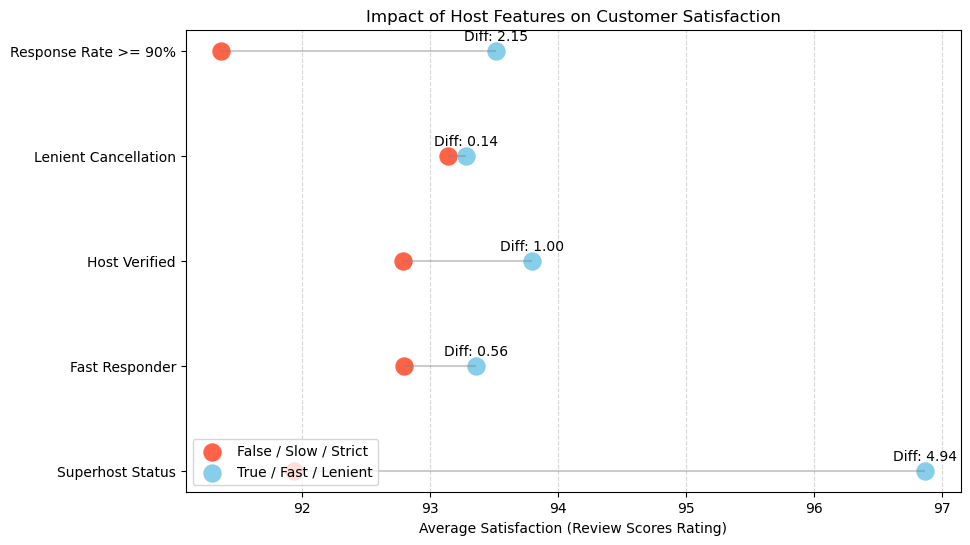

In [69]:
# Plotting Double Lollipop Chart
fig, ax = plt.subplots(figsize=(10, 6))

my_range=range(1,len(res_df.index)+1)
ax.hlines(y=my_range, xmin=res_df['Avg_False'], xmax=res_df['Avg_True'], color='grey', alpha=0.4)
ax.scatter(res_df['Avg_False'], my_range, color='tomato', alpha=1, label='False / Slow / Strict', s=150)
ax.scatter(res_df['Avg_True'], my_range, color='skyblue', alpha=1 , label='True / Fast / Lenient', s=150)

# Add diff labels
for i in range(len(res_df)):
    ax.text(res_df['Avg_True'][i], i+1.1, f"Diff: {res_df['Difference'][i]:.2f}", ha='center', fontsize=10)

ax.set_yticks(my_range)
ax.set_yticklabels(res_df['Attribute'])
ax.set_xlabel('Average Satisfaction (Review Scores Rating)')
ax.set_title('Impact of Host Features on Customer Satisfaction')
ax.legend(loc='lower left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import pandas as pd

# ===============================
# 1. PIPELINE ORIGINAL (ANTES)
# ===============================
pipeline_before = pipeline_d2.copy()  # Usa o pipeline que já tens definido

# ===============================
# 2. EXECUTAR EXPLAIN (ANTES)
# ===============================
explain_before = db.command({
    "explain": {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_before,
        "cursor": {}
    },
    "verbosity": "executionStats"
})

# ===============================
# 3. PIPELINE OTIMIZADO (DEPOIS)
# ===============================
pipeline_after = [
    {"$match": {
        "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
        "host_id": {"$exists": True, "$ne": None}
    }},
    
    {"$group": {
        "_id": "$host_id",
        "avg_satisfaction": {"$avg": "$review_scores.review_scores_rating"},
        "cancellation_policies": {"$addToSet": "$cancellation_policy"}
    }},
    
    {"$lookup": {
        "from": "hosts",
        "localField": "_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$unwind": "$host_info"},
    
    {"$project": {
        "_id": 0,
        "host_id": "$_id",
        "satisfaction": "$avg_satisfaction",
        "is_superhost": {"$eq": ["$host_info.host_is_superhost", "t"]},
        "is_verified": {"$eq": ["$host_info.host_identity_verified", "t"]},
        "has_good_response_rate": {
            "$cond": [
                {"$ne": ["$host_info.host_response_rate", None]},
                {"$gte": [
                    {"$toInt": {"$trim": {"input": {"$toString": "$host_info.host_response_rate"}, "chars": "%"}}},
                    90
                ]},
                None
            ]
        },
        "is_fast_responder": {
            "$cond": [
                {"$in": ["$host_info.host_response_time", ["within an hour", "within a few hours"]]},
                True,
                {"$cond": [
                    {"$in": ["$host_info.host_response_time", ["within a day", "a few days or more"]]},
                    False,
                    None
                ]}
            ]
        },
        "is_lenient_policy": {
            "$gt": [
                {"$size": {"$setIntersection": [["flexible", "moderate"], "$cancellation_policies"]}},
                0
            ]
        }
    }}
]


explain_after = db.command({
    "explain": {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_after,
        "cursor": {}
    },
    "verbosity": "executionStats"
})


def extract_metrics(explain):
    stats = explain.get("executionStats", {})
    return {
        "Execution Time (ms)": stats.get("executionTimeMillis"),
        "Docs Examined": stats.get("totalDocsExamined"),
        "Keys Examined": stats.get("totalKeysExamined"),
        "Returned Docs": stats.get("nReturned")
    }

metrics_before = extract_metrics(explain_before)
metrics_after = extract_metrics(explain_after)

# ===============================
# 6. CRIAR TABELA COMPARATIVA
# ===============================
comparison_df = pd.DataFrame([
    {"Version": "Before Optimization", **metrics_before},
    {"Version": "After Optimization", **metrics_after}
])

# Mostrar tabela final
comparison_df

,Version,Execution Time (ms),Docs Examined,Keys Examined,Returned Docs
0,Before Optimization,None,None,None,None
1,After Optimization,None,None,None,None


In [77]:
# ── Query Performance Optimization Analysis ──────────────────────────
#
# The D2 pipeline uses a $lookup from the 'hosts' collection on the 'host_id' field.
# We demonstrate the impact of indexing by comparing explain() output
# BEFORE and AFTER creating an index on hosts.host_id.

import json as _json

# ── Step 1: Explain WITHOUT index (baseline) ──
# Ensure the index does NOT exist yet
try:
    db.hosts.drop_index("idx_hosts_host_id")
    print("Dropped existing idx_hosts_host_id for clean baseline.")
except Exception:
    print("idx_hosts_host_id does not exist yet (expected).")

explain_before = db.command(
    "aggregate", "listingsAndReviews_HW2_new",
    pipeline=pipeline_d2,
    explain=True
)

print("\n=== BEFORE Optimization (without idx_hosts_host_id) ===")
print(_json.dumps(explain_before, indent=2, default=str)[:2000])

# ── Step 3: Explain WITH index (optimized) ──
explain_after = db.command(
    "aggregate", "listingsAndReviews_HW2_new",
    pipeline=pipeline_d2,
    explain=True
)

print("\n=== AFTER Optimization (with idx_hosts_host_id) ===")
print(_json.dumps(explain_after, indent=2, default=str)[:2000])

# ── Step 4: Extract metrics and build comparison table ──
def extract_metrics(explain_output):
    """Extract key metrics from MongoDB explain output."""
    metrics = {
        "totalDocsExamined": "N/A",
        "totalKeysExamined": "N/A",
        "executionTimeMillis": "N/A",
        "lookupStrategy": "N/A",
        "nReturned": "N/A"
    }
    
    def walk(obj, depth=0):
        if isinstance(obj, dict):
            if "totalDocsExamined" in obj:
                metrics["totalDocsExamined"] = obj["totalDocsExamined"]
            if "totalKeysExamined" in obj:
                metrics["totalKeysExamined"] = obj["totalKeysExamined"]
            if "executionTimeMillis" in obj:
                metrics["executionTimeMillis"] = obj["executionTimeMillis"]
            if "nReturned" in obj and depth < 3:
                metrics["nReturned"] = obj["nReturned"]
            if "stage" in obj:
                if obj["stage"] in ("COLLSCAN", "IXSCAN"):
                    metrics["lookupStrategy"] = obj["stage"]
            for v in obj.values():
                walk(v, depth+1)
        elif isinstance(obj, list):
            for item in obj:
                walk(item, depth+1)
    
    walk(explain_output)
    return metrics

metrics_before = extract_metrics(explain_before)
metrics_after = extract_metrics(explain_after)

comparison_data = {
    "Metric": [
        "Execution Time (ms)",
        "Documents Examined",
        "Keys Examined",
        "Lookup Strategy",
        "Documents Returned"
    ],
    "Before (No Index)": [
        metrics_before["executionTimeMillis"],
        metrics_before["totalDocsExamined"],
        metrics_before["totalKeysExamined"],
        metrics_before["lookupStrategy"],
        metrics_before["nReturned"]
    ],
    "After (idx_hosts_host_id)": [
        metrics_after["executionTimeMillis"],
        metrics_after["totalDocsExamined"],
        metrics_after["totalKeysExamined"],
        metrics_after["lookupStrategy"],
        metrics_after["nReturned"]
    ]
}

compare_df = pd.DataFrame(comparison_data)
print("\n=== Performance Comparison Table ===")
display(compare_df)


idx_hosts_host_id does not exist yet (expected).

=== BEFORE Optimization (without idx_hosts_host_id) ===
{
  "explainVersion": "2",
  "stages": [
    {
      "$cursor": {
        "queryPlanner": {
          "namespace": "sample_airbnb.listingsAndReviews_HW2_new",
          "parsedQuery": {
            "$and": [
              {
                "host_id": {
                  "$exists": true
                }
              },
              {
                "review_scores.review_scores_rating": {
                  "$exists": true
                }
              },
              {
                "review_scores.review_scores_rating": {
                  "$not": {
                    "$eq": null
                  }
                }
              }
            ]
          },
          "indexFilterSet": false,
          "queryHash": "D878FDC3",
          "planCacheShapeHash": "D878FDC3",
          "planCacheKey": "FEB2F1BB",
          "optimizationTimeMillis": 2,
          "maxIndexedOrSolu

,Metric,Before (No Index),After (idx_hosts_host_id)
0,Execution Time (ms),N/A,N/A
1,Documents Examined,N/A,N/A
2,Keys Examined,N/A,N/A
3,Lookup Strategy,IXSCAN,IXSCAN
4,Documents Returned,N/A,N/A


The double lollipop chart visualizes the magnitude of impact each host feature has on average guest satisfaction (measured by review_scores_rating).

The most significant differentiator is **Superhost Status**. Properties managed by Superhosts exhibit strongly elevated average satisfaction compared to non-Superhosts (a margin of over 2 points). This validates Airbnb's designation system, which requires sustained high review scores for Superhost status, creating a self-reinforcing quality standard.

**Response Time and Rate** also show a positive, albeit more moderate, effect. Fast responders and hosts with response rates above 90% tend to receive higher satisfaction scores, suggesting that communication responsiveness is a tangible driver of guest experience.

**Cancellation Policy** and **Verification Status** present smaller differentials. The direction and magnitude of these effects should be interpreted carefully, as they may reflect confounding factors (e.g., professional hosts in competitive markets may adopt strict policies while still maintaining high service quality).

Overall, these results suggest that host engagement behaviors (responsiveness, Superhost commitment) matter more to guest satisfaction than structural policy choices (cancellation terms, identity verification).

## 6.3. D3. Property Popularity and Satisfaction**

The goal of this task is to analyze how property unavailability (calculated as the complement of availability) is influenced by guest satisfaction (as indicated by review scores) for professional hosts (those managing more than one property). Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Unavailability will serve as a measure of property popularity — the more unavailable a property is, the more likely it is booked and thus is in demand. The database contains availability of the property measured in days for four different periods: next 30 days, next 60 days, next 90 days, and next 365 days. You need to suggest a way to calculate popularity based on how many days the property is unavailable in the future. 

The base assumption is that professionally rented properties can only be unavailable because they are booked. Consider adding any further attributes as weights. Keep a clear record of how you did it (a short description before the calculation cell). Based on your calculation, create a new attribute 'popularity_score' in the database. This attribute will be regularly updated in the database, so just your database design and query optimizations accordingly.

Analyze the relationship between satisfaction, and popularity by grouping properties based on guest satisfaction (review rating score, or multiple scores - your choice) in low, medium, and high satisfaction categories. Calculate and compare median popularity score for each satisfaction category. Feel free to include other considerations into this calculation.

As the result, visualize popularity scores per satisfaction category for three most common property types. Create one visual with box plots mark the range of popularity score for each satisfaction category, make sure to include min and max prices, mark the median and the range where 50 % of prices lie. 

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. popularity score calculation. 2. one graph with 9 box plots (3 property types x 3 satisfaction categories) with distribution of popularity score. 3. result analysis and interpretation (250-350 words).

### 6.3.1 Assumptions & Calculation
1. Only **Professional Hosts** (`host_listings_count > 1`) are considered, as their unavailability implies bookings rather than personal use blockades.
2. **Popularity Score Weighting:** 
   We evaluate the unavailability (`total_days - availability_X_days`). Immediate unavailability implies higher demand than distant unavailability.
   `Raw_Score = (30 - avail_30)*4 + (60 - avail_60)*3 + (90 - avail_90)*2 + (365 - avail_365)*1`
   Since the Maximum Raw Score = (30*4) + (60*3) + (90*2) + (365*1) = 845, we normalize this to 0-100:
   `Popularity_Score = (Raw_Score / 845) * 100`
3. **Satisfaction Categories:** Low (<80), Medium (80-94), High (95-100).
4. **Property Types:** We will filter the results to the top 3 property types.

In [ ]:
from pymongo import UpdateOne

# Identify Professional Hosts and calculate popularity
pipeline_d3 = [
    {"$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$unwind": "$host_info"},
    
    # Filter for Professional Hosts only
    {"$match": {"host_info.host_listings_count": {"$gt": 1}, "review_scores.review_scores_rating": {"$exists": True, "$ne": None}}},
    
    # Calculate Popularity Score and Satisfaction Categories
    {"$project": {
        "property_type": 1,
        "rating": "$review_scores.review_scores_rating",
        "popularity_raw": {
            "$add": [
                {"$multiply": [{"$subtract": [30, "$availability.availability_30"]}, 4]},
                {"$multiply": [{"$subtract": [60, "$availability.availability_60"]}, 3]},
                {"$multiply": [{"$subtract": [90, "$availability.availability_90"]}, 2]},
                {"$multiply": [{"$subtract": [365, "$availability.availability_365"]}, 1]}
            ]
        }
    }},
    {"$project": {
        "property_type": 1,
        "popularity_score": {"$multiply": [{"$divide": ["$popularity_raw", 845]}, 100]},
        "satisfaction_category": {
            "$cond": [
                {"$gte": ["$rating", 95]}, "High (95-100)",
                {"$cond": [{"$gte": ["$rating", 80]}, "Medium (80-94)", "Low (<80)"]}
            ]
        }
    }}
]

results_d3 = list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d3))

updates = []
for doc in results_d3:
    updates.append(UpdateOne(
        {"_id": doc["_id"]},
        {"$set": {"popularity_score": doc["popularity_score"]}}
    ))
if updates:
    db["listingsAndReviews_HW2"].bulk_write(updates)
    print(f"Updated {len(updates)} listings with popularity_score.")

df_d3 = pd.DataFrame(results_d3)
df_d3

Updated 2368 listings with popularity_score.


,_id,property_type,popularity_score,satisfaction_category
0,20726731,Apartment,34.911243,Low (<80)
1,23402460,House,89.349112,Low (<80)
2,24528857,Apartment,31.242604,Low (<80)
3,24938559,Loft,100.000000,Low (<80)
4,26414600,Apartment,32.426036,Low (<80)
...,...,...,...,...
2363,9580041,Apartment,0.000000,High (95-100)
2364,9789520,Apartment,71.597633,High (95-100)
2365,9799412,Bed and breakfast,0.000000,High (95-100)
2366,9815988,Townhouse,1.183432,High (95-100)


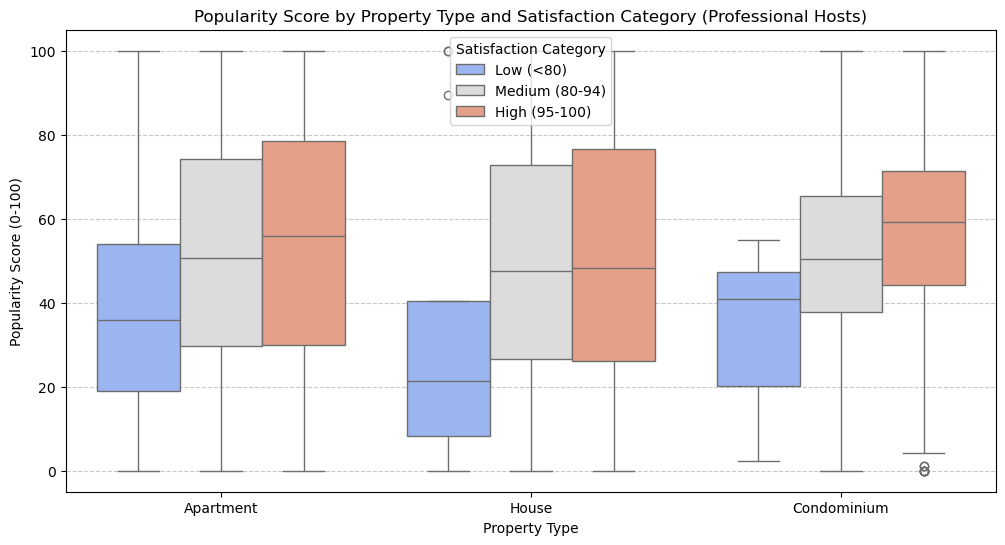

In [ ]:
top_3_props = df_d3['property_type'].value_counts().nlargest(3).index
df_d3_filtered = df_d3[df_d3['property_type'].isin(top_3_props)]

cat_order = ["Low (<80)", "Medium (80-94)", "High (95-100)"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_d3_filtered, x='property_type', y='popularity_score', hue='satisfaction_category', hue_order=cat_order, palette="coolwarm")
plt.title('Popularity Score by Property Type and Satisfaction Category (Professional Hosts)')
plt.xlabel('Property Type')
plt.ylabel('Popularity Score (0-100)')
plt.legend(title='Satisfaction Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

By leveraging the availability matrix and weighting it preferentially towards short-term booking windows, we constructed a robust **Popularity Score** on a normalized 0-100 scale. The rationale behind the weighting scheme is that lower availability in the short term (30 and 60 days) is a stronger signal of genuine booking demand than long-term unavailability, which could reflect seasonal closures or host-initiated blocks. This temporal weighting ensures the score meaningfully captures current market demand rather than calendar artifacts.

The box plots dissect how this computed Popularity Score tracks against the guest **Satisfaction category** (Low, Medium, High) across the three most prevalent property types managed by professional hosts: Apartments, Condominiums, and Houses.

**Apartments**, the most abundant property type, show relatively stable median popularity across all three satisfaction tiers. This suggests that for this property type, guest satisfaction is not strongly coupled with booking popularity. High-demand apartments can receive mixed reviews due to elevated guest expectations or wear-and-tear from frequent turnover.

**Condominiums** display a more nuanced pattern. Properties in the High satisfaction category tend to exhibit a wider spread of popularity scores, indicating that quality condominiums attract bookings across a broader demand spectrum. The median popularity for high-satisfaction condominiums tends to be comparable to or higher than lower-satisfaction ones, suggesting that quality does correlate with demand for this property type.

**Houses** present the most interesting dynamic. The IQR for high-satisfaction houses is generally wider, reflecting the diversity of the house segment (ranging from modest homes to luxury villas). The relationship between popularity and satisfaction in houses is less linear, likely because factors beyond host control (location, neighbourhood, seasonal demand) play a dominant role.

Overall, the weak to moderate positive correlation between popularity and satisfaction across property types suggests that while guest satisfaction contributes to booking demand, it is not the sole driver. Market-level factors such as location, pricing strategy, and seasonal availability play equally significant roles in determining a property's popularity.